In [1]:
!pip install pesq

  Preparing metadata (setup.py) ... done
  Created wheel for pesq: filename=pesq-0.0.4-cp312-cp312-linux_x86_64.whl size=284118 sha256=9ce356b2f15864e2ae308c802a8c559a6e19514daa92bcbc4581e628a767fa7a
  Stored in directory: /root/.cache/pip/wheels/9b/d4/a4/9cf3512534cd47ce4a036d1593ee4013f2bf7509e631a147a3
Successfully built pesq


In [2]:
import os
import numpy as np
import librosa
import soundfile as sf
import warnings

# Suppress librosa warnings for cleaner outputs
warnings.filterwarnings("ignore")

class AudioStegoEnv:
    def __init__(self, target_duration=10.0, sr=22050, frame_size=1024, hop_size=512):
        self.target_duration = target_duration
        self.sr = sr
        self.frame_size = frame_size
        self.hop_size = hop_size
        self.target_samples = int(target_duration * sr)

    def load_and_preprocess(self, file_path):
        """
        Loads audio, forces 16-bit PCM format, and standardizes length.
        """
        # Load audio using librosa (loads as float32 by default)
        audio, _ = librosa.load(file_path, sr=self.sr)
        
        # Trim or pad to exact target duration (10 seconds)
        if len(audio) > self.target_samples:
            audio = audio[:self.target_samples]
        else:
            audio = np.pad(audio, (0, self.target_samples - len(audio)), mode='constant')
            
        # Convert to 16-bit integer PCM for LSB manipulation
        # Multiply by max int16 value and cast
        audio_int16 = np.int16(audio * 32767)
        
        return audio_int16

    def get_audio_float(self, audio_int16):
        """Convert back to float for librosa feature extraction"""
        return audio_int16.astype(np.float32) / 32767.0

In [3]:
class FeatureExtractor:
    def __init__(self, frame_size=1024, hop_size=512, sr=22050):
        self.frame_size = frame_size
        self.hop_size = hop_size
        self.sr = sr

    def extract_features(self, audio_float):
        """
        Extracts perceptual features per frame.
        Returns a dictionary of normalized feature arrays, ensuring all have the same length.
        """
        # 1-4: Standard librosa features (these use center=True by default)
        rms = librosa.feature.rms(y=audio_float, frame_length=self.frame_size, hop_length=self.hop_size)[0]
        flatness = librosa.feature.spectral_flatness(y=audio_float, n_fft=self.frame_size, hop_length=self.hop_size)[0]
        centroid = librosa.feature.spectral_centroid(y=audio_float, sr=self.sr, n_fft=self.frame_size, hop_length=self.hop_size)[0]
        zcr = librosa.feature.zero_crossing_rate(y=audio_float, frame_length=self.frame_size, hop_length=self.hop_size)[0]
        
        # 5. Spectral Flux
        S = np.abs(librosa.stft(audio_float, n_fft=self.frame_size, hop_length=self.hop_size))
        flux = np.sum(np.maximum(0, np.diff(S, axis=1)), axis=0)
        flux = np.pad(flux, (1, 0), mode='constant') # Pad to match frame counts
        
        # 6. Local SNR Estimation (FIXED)
        # We manually pad the audio here using 'reflect' mode to exactly match 
        # librosa's default center=True behavior used in the features above.
        pad_length = int(self.frame_size // 2)
        padded_audio = np.pad(audio_float, pad_length, mode='reflect')
        
        frames = librosa.util.frame(padded_audio, frame_length=self.frame_size, hop_length=self.hop_size)
        signal_var = np.var(frames, axis=0)
        noise_floor = np.percentile(signal_var, 10) + 1e-6 
        local_snr = 10 * np.log10(signal_var / noise_floor)
        local_snr = np.clip(local_snr, 0, None) 

        # Normalize all features to [0, 1] range
        features = {
            'energy': self._normalize(rms),
            'flatness': self._normalize(flatness),
            'centroid': self._normalize(centroid),
            'zcr': self._normalize(zcr),
            'flux': self._normalize(flux),
            'snr': self._normalize(local_snr)
        }
        
        # Quick safety check to ensure all shapes perfectly match before returning
        lengths = [len(v) for v in features.values()]
        assert len(set(lengths)) == 1, f"Shape mismatch detected! Lengths: {lengths}"
        
        return features

    def _normalize(self, array):
        """Min-max normalization to [0, 1]"""
        min_val = np.min(array)
        max_val = np.max(array)
        if max_val == min_val:
            return np.zeros_like(array)
        return (array - min_val) / (max_val - min_val)

In [4]:
# Assuming GTZAN dataset is mounted in Kaggle at this path
# Update the path if yours is slightly different
sample_file = "/kaggle/input/datasets/ayushcosmos/no-music/freesound_community-mensagem-no-celular-101471.mp3"

env = AudioStegoEnv()
extractor = FeatureExtractor()

# Load and process
audio_int = env.load_and_preprocess(sample_file)
audio_float = env.get_audio_float(audio_int)

# Extract features
features = extractor.extract_features(audio_float)

print(f"Audio shape (16-bit PCM): {audio_int.shape}")
print(f"Number of frames extracted: {features['energy'].shape[0]}")
print(f"Sample Normalized Energy values: {features['energy'][:5]}")

Audio shape (16-bit PCM): (220500,)
Number of frames extracted: 431
Sample Normalized Energy values: [0. 0. 0. 0. 0.]


In [5]:
# class FuzzyLogicSystem:
#     def __init__(self):
#         # Tuned thresholds to match the new normalized score distribution
#         self.t_high = 0.45
#         self.t_med = 0.25
#         self.t_low = 0.10

#     def compute_scores(self, features):
#         """
#         Applies a 'Soft' Fuzzy Logic using your specific feature groupings.
#         """
#         E = features['energy']
#         SNR = features['snr']
#         Flux = features['flux']
#         ZCR = features['zcr']
#         Flat = features['flatness']
#         Cent = features['centroid']
        
#         # We use averaging instead of np.minimum. 
#         # This prevents a single 0.0 feature from instantly killing the score.
#         r1 = (E + SNR + Flux) / 3.0
#         r2 = (ZCR + Flat) / 2.0
#         r3 = (Cent + E) / 2.0
#         r4 = ((1.0 - E) + (1.0 - SNR)) / 2.0
        
#         # Aggregate using your exact logic, but with a slightly softened penalty
#         raw_score = (0.4 * r1) + (0.3 * r2) + (0.2 * r3) - (0.25 * r4)
        
#         return np.clip(raw_score, 0, 1)

#     def map_to_bits(self, scores):
#         bit_depths = np.zeros_like(scores, dtype=np.uint8)
        
#         bit_depths[scores > self.t_high] = 3
#         bit_depths[(scores > self.t_med) & (scores <= self.t_high)] = 2
#         bit_depths[(scores > self.t_low) & (scores <= self.t_med)] = 1
        
#         return bit_depths

#     def calculate_capacity(self, bit_depths, hop_size):
#         total_bits = np.sum(bit_depths.astype(int) * hop_size)
#         total_bytes = total_bits / 8
#         total_kb = total_bytes / 1024
#         return int(total_bits), total_kb

class FuzzyLogicSystem:
    def __init__(self):
        # Slightly adjusted thresholds. We let the improved math do the heavy lifting
        # rather than just lowering the floodgates.
        self.t_high = 0.40
        self.t_med = 0.22
        self.t_low = 0.08

    def compute_scores(self, features):
        """
        Optimized Fuzzy Logic: Prioritizes chaotic/noisy textures over raw volume.
        """
        E = features['energy']
        SNR = features['snr']
        Flux = features['flux']
        ZCR = features['zcr']
        Flat = features['flatness']
        Cent = features['centroid']
        
        # Rule 1: Transients & Loudness. Good, but not the best.
        r1 = (0.4 * E) + (0.3 * Flux) + (0.3 * SNR)
        
        # Rule 2: Chaotic Textures (Noisy/Static sounds). 
        # This is the holy grail for LSB steganography.
        r2 = (0.5 * ZCR) + (0.5 * Flat)
        
        # Rule 3: Brightness. Higher frequencies mask digital static better.
        r3 = Cent
        
        # The Multiplicative Penalty: 
        # Only heavily penalizes if the frame is BOTH very quiet AND very clean.
        # This frees up the "mid-range" frames to hold 1 or 2 bits safely.
        penalty = (1.0 - E) * (1.0 - SNR)
        
        # Aggregate: We now heavily favor R2 (Texture) and soften the penalty.
        raw_score = (0.35 * r1) + (0.45 * r2) + (0.20 * r3) - (0.15 * penalty)
        
        return np.clip(raw_score, 0, 1)

    def map_to_bits(self, scores):
        bit_depths = np.zeros_like(scores, dtype=np.uint8)
        
        bit_depths[scores >= self.t_high] = 3
        bit_depths[(scores >= self.t_med) & (scores < self.t_high)] = 2
        bit_depths[(scores >= self.t_low) & (scores < self.t_med)] = 1
        
        return bit_depths

    def calculate_capacity(self, bit_depths, hop_size):
        total_bits = np.sum(bit_depths.astype(int) * hop_size)
        total_bytes = total_bits / 8
        total_kb = total_bytes / 1024
        return int(total_bits), total_kb

In [6]:
# Assuming you already ran env.load_and_preprocess and extractor.extract_features
fuzzy_sys = FuzzyLogicSystem()

# Get scores and bit depths
fuzzy_scores = fuzzy_sys.compute_scores(features)
bit_depth_per_frame = fuzzy_sys.map_to_bits(fuzzy_scores)

# Calculate Capacity
total_bits, total_kb = fuzzy_sys.calculate_capacity(bit_depth_per_frame, env.hop_size)

print(f"Fuzzy Scores (first 5): {fuzzy_scores[:5]}")
print(f"Bit Depths (first 5): {bit_depth_per_frame[:5]}")
print(f"Total Embedded Bits: {total_bits}")
print(f"Total Capacity: {total_kb:.2f} KB")

# Quick stats on bit distribution
unique, counts = np.unique(bit_depth_per_frame, return_counts=True)
print(f"Bit depth distribution (frames): {dict(zip(unique, counts))}")

Fuzzy Scores (first 5): [0.07499999 0.07499999 0.07499999 0.07499999 0.07499999]
Bit Depths (first 5): [0 0 0 0 0]
Total Embedded Bits: 280576
Total Capacity: 34.25 KB
Bit depth distribution (frames): {np.uint8(0): np.int64(149), np.uint8(1): np.int64(94), np.uint8(2): np.int64(110), np.uint8(3): np.int64(78)}


In [7]:
class EmbeddingEngine:
    def __init__(self, hop_size=512):
        self.hop_size = hop_size

    def _create_sample_map(self, bit_depths, audio_length):
        sample_map = np.zeros(audio_length, dtype=np.uint8)
        for i, bits in enumerate(bit_depths):
            start = i * self.hop_size
            end = min(start + self.hop_size, audio_length)
            sample_map[start:end] = bits
        return sample_map

    def generate_random_payload(self, capacity_bits):
        return np.random.randint(0, 2, size=capacity_bits, dtype=np.uint8)

    def calculate_exact_capacity(self, bit_depths, audio_length):
        sample_map = self._create_sample_map(bit_depths, audio_length)
        return int(np.sum(sample_map, dtype=np.int64))

    def embed(self, audio_int16, bit_depths, payload_bits):
        # Use astype to safely convert negative ints to positive 16-bit representations
        audio_stego = audio_int16.astype(np.uint16)
        sample_map = self._create_sample_map(bit_depths, len(audio_stego))
        
        payload_idx = 0
        payload_len = len(payload_bits)
        
        for i in range(len(audio_stego)):
            # FORCE standard Python integer to prevent NumPy 8-bit truncation
            bits = int(sample_map[i]) 
            
            if bits > 0 and payload_idx < payload_len:
                bits_chunk = payload_bits[payload_idx : payload_idx + bits]
                payload_idx += len(bits_chunk)
                
                if len(bits_chunk) < bits:
                    bits_chunk = np.pad(bits_chunk, (0, bits - len(bits_chunk)))
                    
                val_to_embed = 0
                for bit in bits_chunk:
                    val_to_embed = (val_to_embed << 1) | int(bit)
                    
                # A much safer way to build the mask without the NOT (~) operator
                # 0xFFFF is 65535. XORing it flips the bits safely.
                clear_mask = 0xFFFF ^ ((1 << bits) - 1)
                
                # Do math in standard Python integer space, then put it back
                current_val = int(audio_stego[i])
                new_val = (current_val & clear_mask) | val_to_embed
                audio_stego[i] = new_val
                
        # Cast back to signed integers
        return audio_stego.astype(np.int16)

    def extract(self, audio_stego, bit_depths, num_bits_to_extract):
        audio_uint16 = audio_stego.astype(np.uint16)
        sample_map = self._create_sample_map(bit_depths, len(audio_uint16))
        extracted_bits = []
        
        for i in range(len(audio_uint16)):
            bits = int(sample_map[i])
            
            if bits > 0:
                val = int(audio_uint16[i])
                mask = (1 << bits) - 1
                extracted_val = val & mask
                
                # Extract bit by bit
                for j in range(bits - 1, -1, -1):
                    extracted_bits.append((extracted_val >> j) & 1)
                    
                    if len(extracted_bits) == num_bits_to_extract:
                        return np.array(extracted_bits, dtype=np.uint8)
                        
        return np.array(extracted_bits, dtype=np.uint8)

In [8]:
# Initialize our engine
embed_engine = EmbeddingEngine(hop_size=env.hop_size)

# Calculate EXACT capacity based on the actual audio array length
exact_bits = embed_engine.calculate_exact_capacity(bit_depth_per_frame, len(audio_int))
print(f"Theoretical Capacity (Step 3): {total_bits} bits")
print(f"Exact Usable Capacity: {exact_bits} bits")

# 1. Generate payload with the EXACT capacity
payload = embed_engine.generate_random_payload(exact_bits)

# 2. Embed the payload
audio_stego = embed_engine.embed(audio_int, bit_depth_per_frame, payload)
print("Embedding successful!")

# 3. Extract the payload
extracted_payload = embed_engine.extract(audio_stego, bit_depth_per_frame, len(payload))

# 4. Verify
is_match = np.array_equal(payload, extracted_payload)
print(f"Extraction Match: {is_match}")

Theoretical Capacity (Step 3): 280576 bits
Exact Usable Capacity: 280404 bits
Embedding successful!
Extraction Match: True


In [9]:
# --- DEBUGGING BLOCK ---

print(f"Original Payload Length: {len(payload)}")
print(f"Extracted Payload Length: {len(extracted_payload)}")

# 1. Check if lengths mismatched first
if len(payload) != len(extracted_payload):
    print("\n[!] Length Mismatch! The extraction loop stopped early or went too long.")
    min_len = min(len(payload), len(extracted_payload))
else:
    min_len = len(payload)

# 2. Find the exact indices where the bits don't match
mismatches = np.where(payload[:min_len] != extracted_payload[:min_len])[0]

print(f"Total Mismatched Bits: {len(mismatches)} out of {min_len}")

# 3. If there are mismatches, let's dissect the first 3 failures
if len(mismatches) > 0:
    print("\n--- Dissecting First 3 Failures ---")
    
    # We need to map the bit index back to the audio sample index to see the integer
    sample_map = embed_engine._create_sample_map(bit_depth_per_frame, len(audio_int))
    
    # Rebuild the mapping of bit_index -> audio_sample_index
    bit_to_sample_idx = []
    for i in range(len(sample_map)):
        bits = sample_map[i]
        for _ in range(bits):
            bit_to_sample_idx.append(i)
            
    for bit_idx in mismatches[:3]:
        sample_idx = bit_to_sample_idx[bit_idx]
        bits_embedded = sample_map[sample_idx]
        
        orig_val = audio_int[sample_idx]
        stego_val = audio_stego[sample_idx]
        
        print(f"\n[Bit Index {bit_idx}]")
        print(f"  Target Bit Value : {payload[bit_idx]}")
        print(f"  Extracted Bit    : {extracted_payload[bit_idx]}")
        print(f"  Audio Sample Idx : {sample_idx}")
        print(f"  Local Bit Depth  : {bits_embedded} bits")
        print(f"  Original Int16   : {orig_val} (Binary: {np.binary_repr(orig_val, width=16)})")
        print(f"  Stego Int16      : {stego_val} (Binary: {np.binary_repr(stego_val, width=16)})")

Original Payload Length: 280404
Extracted Payload Length: 280404
Total Mismatched Bits: 0 out of 280404


In [10]:
from pesq import pesq
import librosa
import soundfile as sf # Added for saving audio
import numpy as np

class Evaluator:
    @staticmethod
    def calculate_metrics(original_audio, stego_audio, sr=22050):
        """Computes SNR, MSE, PSNR, and PESQ."""
        orig = original_audio.astype(np.float64)
        stego = stego_audio.astype(np.float64)
        
        mse = np.mean((orig - stego) ** 2)
        if mse == 0:
            return float('inf'), 0.0, float('inf'), 4.5 # Perfect MOS
            
        signal_power = np.mean(orig ** 2)
        snr = 10 * np.log10(signal_power / mse)
        
        max_pixel = 32767.0 
        psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
        
        # --- PERCEPTUAL METRIC (PESQ) ---
        try:
            orig_16k = librosa.resample(orig, orig_sr=sr, target_sr=16000)
            stego_16k = librosa.resample(stego, orig_sr=sr, target_sr=16000)
            pesq_score = pesq(16000, orig_16k, stego_16k, 'wb')
        except Exception as e:
            print(f"PESQ Calculation Failed: {e}")
            pesq_score = 0.0
            
        return snr, mse, psnr, pesq_score

class BaselineMethods:
    def __init__(self, embed_engine):
        self.engine = embed_engine

    def run_fixed_lsb(self, audio_int, fixed_depth):
        """Runs a baseline where every frame gets the exact same bit depth."""
        num_frames = int(np.ceil(len(audio_int) / self.engine.hop_size))
        fixed_bit_depths = np.full(num_frames, fixed_depth, dtype=np.uint8)
        
        exact_bits = self.engine.calculate_exact_capacity(fixed_bit_depths, len(audio_int))
        payload = self.engine.generate_random_payload(exact_bits)
        stego_audio = self.engine.embed(audio_int, fixed_bit_depths, payload)
        
        return stego_audio, exact_bits

# --- RUN THE GRAND COMPARISON (UPDATED FOR SAVING FILES) ---
evaluator = Evaluator()
baselines = BaselineMethods(embed_engine)

print("--- PERFORMANCE COMPARISON ---")

# We will save the files to the current Kaggle working directory
output_dir = "/kaggle/working/" 

# 1. Your Adaptive Fuzzy Method
snr_adapt, mse_adapt, psnr_adapt, pesq_adapt = evaluator.calculate_metrics(audio_int, audio_stego)
print(f"\n[Adaptive Fuzzy System]")
print(f"Capacity : {exact_bits / (8*1024):.2f} KB")
print(f"SNR      : {snr_adapt:.2f} dB")
print(f"PSNR     : {psnr_adapt:.2f} dB")
print(f"PESQ     : {pesq_adapt:.2f} (MOS)")
# SAVE ADAPTIVE AUDIO
sf.write(f"{output_dir}stego_adaptive.wav", audio_stego, env.sr, subtype='PCM_16')

# 2. Baseline: Standard 1-bit LSB
stego_1bit, bits_1bit = baselines.run_fixed_lsb(audio_int, fixed_depth=1)
snr_1bit, _, psnr_1bit, pesq_1bit = evaluator.calculate_metrics(audio_int, stego_1bit)
print(f"\n[Standard 1-Bit LSB]")
print(f"Capacity : {bits_1bit / (8*1024):.2f} KB")
print(f"SNR      : {snr_1bit:.2f} dB")
print(f"PSNR     : {psnr_1bit:.2f} dB")
print(f"PESQ     : {pesq_1bit:.2f} (MOS)")
# SAVE 1-BIT AUDIO
sf.write(f"{output_dir}stego_1bit.wav", stego_1bit, env.sr, subtype='PCM_16')

# 3. Baseline: Fixed 3-bit LSB
stego_3bit, bits_3bit = baselines.run_fixed_lsb(audio_int, fixed_depth=5)
snr_3bit, _, psnr_3bit, pesq_3bit = evaluator.calculate_metrics(audio_int, stego_3bit)
print(f"\n[Fixed 3-Bit LSB]")
print(f"Capacity : {bits_3bit / (8*1024):.2f} KB")
print(f"SNR      : {snr_3bit:.2f} dB")
print(f"PSNR     : {psnr_3bit:.2f} dB")
print(f"PESQ     : {pesq_3bit:.2f} (MOS)")
# SAVE 3-BIT AUDIO
sf.write(f"{output_dir}stego_5bit.wav", stego_3bit, env.sr, subtype='PCM_16')

# (Optional) Save the original file for a clean A/B comparison
sf.write(f"{output_dir}original_clean.wav", audio_int, env.sr, subtype='PCM_16')
print("\n[+] All audio files successfully saved to /kaggle/working/!")

--- PERFORMANCE COMPARISON ---

[Adaptive Fuzzy System]
Capacity : 34.23 KB
SNR      : 46.99 dB
PSNR     : 86.09 dB
PESQ     : 4.36 (MOS)

[Standard 1-Bit LSB]
Capacity : 26.92 KB
SNR      : 54.22 dB
PSNR     : 93.32 dB
PESQ     : 4.59 (MOS)

[Fixed 3-Bit LSB]
Capacity : 134.58 KB
SNR      : 28.56 dB
PSNR     : 67.67 dB
PESQ     : 1.88 (MOS)

[+] All audio files successfully saved to /kaggle/working/!


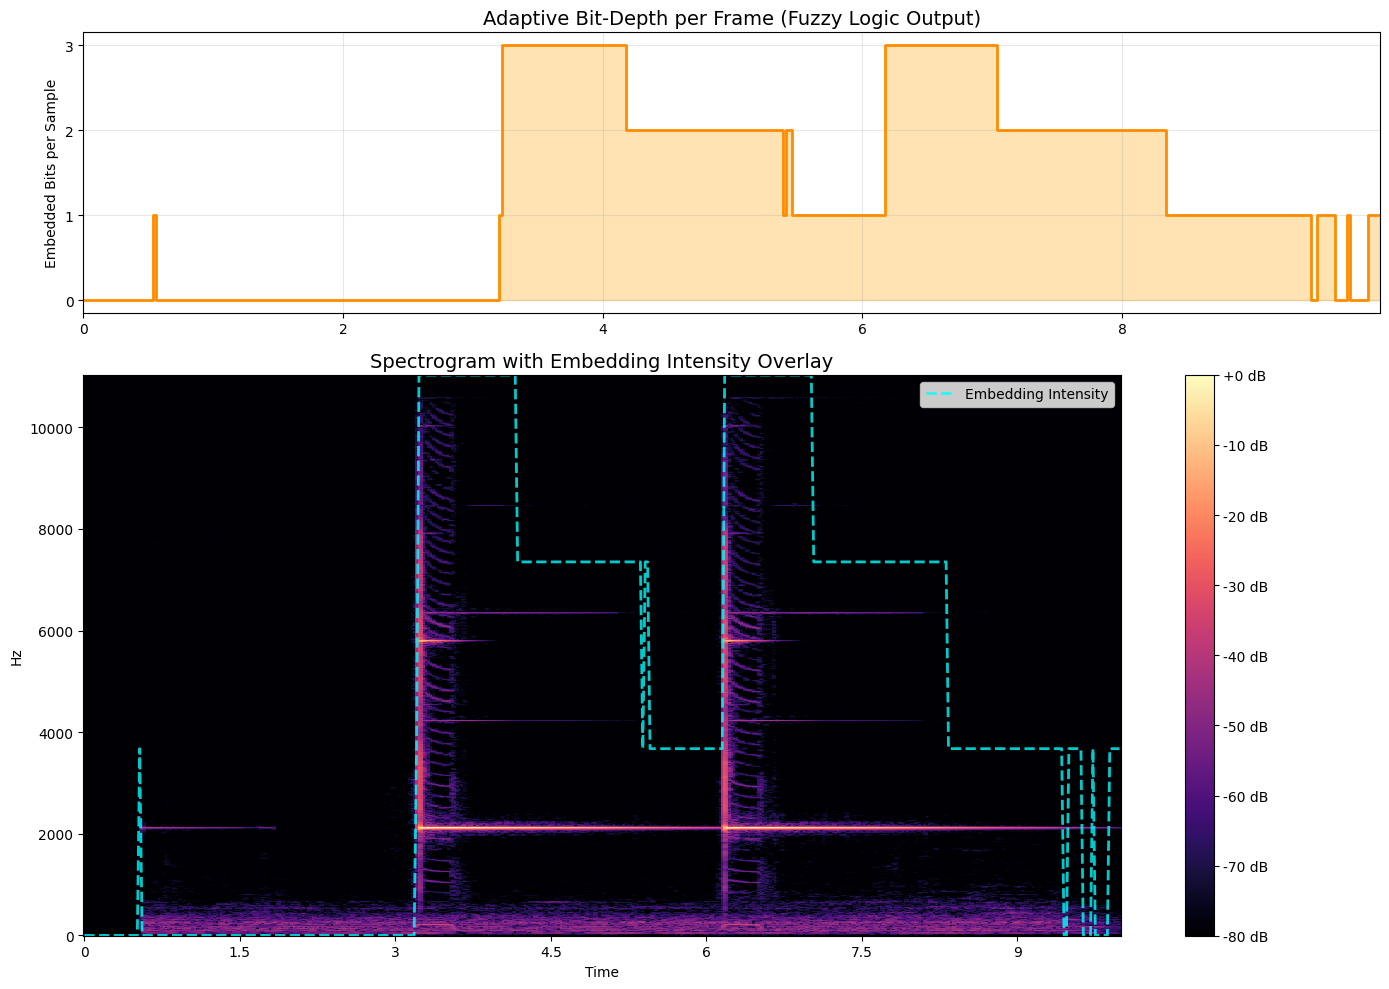

In [11]:
import matplotlib.pyplot as plt
import librosa.display

def visualize_single_track(audio_float, bit_depths, sr=22050, hop_size=512):
    fig, ax = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 2]})
    
    # Time axis for the frames
    times = librosa.frames_to_time(np.arange(len(bit_depths)), sr=sr, hop_length=hop_size)
    
    # PLOT 1: The Bit-Depth Map
    ax[0].step(times, bit_depths, where='post', color='darkorange', linewidth=2)
    ax[0].fill_between(times, bit_depths, step='post', alpha=0.3, color='orange')
    ax[0].set_title('Adaptive Bit-Depth per Frame (Fuzzy Logic Output)', fontsize=14)
    ax[0].set_ylabel('Embedded Bits per Sample')
    ax[0].set_yticks([0, 1, 2, 3])
    ax[0].set_xlim([times[0], times[-1]])
    ax[0].grid(True, alpha=0.3)
    
    # PLOT 2: Spectrogram Overlay
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_float, hop_length=hop_size)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, hop_length=hop_size, x_axis='time', y_axis='hz', ax=ax[1], cmap='magma')
    
    # Overlay the bit map on the spectrogram to show *where* we are embedding heavily
    # We scale the bit depths (0-3) to fit the frequency axis visually
    max_freq = sr / 2
    scaled_bits = (bit_depths / 3.0) * max_freq
    ax[1].plot(times, scaled_bits, color='cyan', alpha=0.8, linewidth=2, linestyle='--', label='Embedding Intensity')
    
    ax[1].set_title('Spectrogram with Embedding Intensity Overlay', fontsize=14)
    ax[1].legend(loc='upper right')
    fig.colorbar(img, ax=ax[1], format="%+2.0f dB")
    
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_single_track(audio_float, bit_depth_per_frame, sr=env.sr, hop_size=env.hop_size)

In [12]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

def run_genre_evaluation(base_path, genres_to_test, samples_per_genre=5):
    results = {'Genre': [], 'Adapt_Cap': [], 'Adapt_SNR': [], '1Bit_Cap': [], '1Bit_SNR': []}
    
    # Initialize our engines
    env = AudioStegoEnv()
    extractor = FeatureExtractor()
    fuzzy_sys = FuzzyLogicSystem()
    
    # Let's make the fuzzy logic slightly greedier for the final test
    fuzzy_sys.t_high = 0.35
    fuzzy_sys.t_med = 0.20
    fuzzy_sys.t_low = 0.05
    
    embed_engine = EmbeddingEngine(hop_size=env.hop_size)
    evaluator = Evaluator()
    baselines = BaselineMethods(embed_engine)
    
    for genre in genres_to_test:
        genre_path = os.path.join(base_path, genre, f"{genre}.*.wav")
        files = glob.glob(genre_path)[:samples_per_genre]
        
        if not files:
            print(f"Warning: No files found for {genre} at {genre_path}")
            continue
            
        print(f"Processing [{genre.upper()}]...")
        
        genre_adapt_cap, genre_adapt_snr = [], []
        genre_1bit_cap, genre_1bit_snr = [], []
        
        for file in files:
            # 1. Load and Extract
            audio_int = env.load_and_preprocess(file)
            audio_float = env.get_audio_float(audio_int)
            features = extractor.extract_features(audio_float)
            
            # 2. Fuzzy Adaptive Run
            scores = fuzzy_sys.compute_scores(features)
            bit_depths = fuzzy_sys.map_to_bits(scores)
            exact_bits = embed_engine.calculate_exact_capacity(bit_depths, len(audio_int))
            
            payload = embed_engine.generate_random_payload(exact_bits)
            stego_audio = embed_engine.embed(audio_int, bit_depths, payload)
            snr, _, _ = evaluator.calculate_metrics(audio_int, stego_audio)
            
            genre_adapt_cap.append(exact_bits / (8 * 1024)) # KB
            genre_adapt_snr.append(snr)
            
            # 3. 1-Bit Baseline Run
            stego_1bit, bits_1bit = baselines.run_fixed_lsb(audio_int, fixed_depth=1)
            snr_1bit, _, _ = evaluator.calculate_metrics(audio_int, stego_1bit)
            
            genre_1bit_cap.append(bits_1bit / (8 * 1024))
            genre_1bit_snr.append(snr_1bit)
            
        # Average the results for the genre
        results['Genre'].append(genre)
        results['Adapt_Cap'].append(np.mean(genre_adapt_cap))
        results['Adapt_SNR'].append(np.mean(genre_adapt_snr))
        results['1Bit_Cap'].append(np.mean(genre_1bit_cap))
        results['1Bit_SNR'].append(np.mean(genre_1bit_snr))
        
    return results

def plot_genre_results(results):
    genres = results['Genre']
    x = np.arange(len(genres))
    width = 0.35
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # --- PLOT 1: Capacity Comparison ---
    rects1 = ax1.bar(x - width/2, results['Adapt_Cap'], width, label='Adaptive (Fuzzy)', color='royalblue')
    rects2 = ax1.bar(x + width/2, results['1Bit_Cap'], width, label='1-Bit LSB', color='lightcoral')
    
    ax1.set_ylabel('Capacity (KB)')
    ax1.set_title('Payload Capacity by Genre')
    ax1.set_xticks(x)
    ax1.set_xticklabels([g.capitalize() for g in genres])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # --- PLOT 2: SNR Comparison ---
    rects3 = ax2.bar(x - width/2, results['Adapt_SNR'], width, label='Adaptive (Fuzzy)', color='seagreen')
    rects4 = ax2.bar(x + width/2, results['1Bit_SNR'], width, label='1-Bit LSB', color='orange')
    
    ax2.set_ylabel('SNR (dB)')
    ax2.set_title('Audio Quality (SNR) by Genre')
    ax2.set_xticks(x)
    ax2.set_xticklabels([g.capitalize() for g in genres])
    ax2.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Audibility Threshold (~30dB)')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Set up your dataset path here
# Ensure this matches your Kaggle GTZAN path
gtzan_base_path = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original"
genres_to_test = ['metal', 'blues', 'pop', 'classical','rock']

# Run the evaluation and plot!
print("Starting Full Evaluation Pipeline...")
final_results = run_genre_evaluation(gtzan_base_path, genres_to_test)
plot_genre_results(final_results)

Starting Full Evaluation Pipeline...
Processing [METAL]...


ValueError: too many values to unpack (expected 3)

In [13]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

def run_genre_evaluation(base_path, genres_to_test, samples_per_genre=5):
    # Added 3Bit_Cap and 3Bit_SNR to our results dictionary
    results = {
        'Genre': [], 
        'Adapt_Cap': [], 'Adapt_SNR': [], 
        '1Bit_Cap': [], '1Bit_SNR': [],
        '3Bit_Cap': [], '3Bit_SNR': []
    }
    
    env = AudioStegoEnv()
    extractor = FeatureExtractor()
    fuzzy_sys = FuzzyLogicSystem()
    
    fuzzy_sys.t_high = 0.35
    fuzzy_sys.t_med = 0.20
    fuzzy_sys.t_low = 0.05
    
    embed_engine = EmbeddingEngine(hop_size=env.hop_size)
    evaluator = Evaluator()
    baselines = BaselineMethods(embed_engine)
    
    for genre in genres_to_test:
        genre_path = os.path.join(base_path, genre, f"{genre}.*.wav")
        files = glob.glob(genre_path)[:samples_per_genre]
        
        if not files:
            print(f"Warning: No files found for {genre} at {genre_path}")
            continue
            
        print(f"Processing [{genre.upper()}]...")
        
        genre_adapt_cap, genre_adapt_snr = [], []
        genre_1bit_cap, genre_1bit_snr = [], []
        genre_3bit_cap, genre_3bit_snr = [], []
        
        for file in files:
            # 1. Load and Extract
            audio_int = env.load_and_preprocess(file)
            audio_float = env.get_audio_float(audio_int)
            features = extractor.extract_features(audio_float)
            
            # 2. Fuzzy Adaptive Run
            scores = fuzzy_sys.compute_scores(features)
            bit_depths = fuzzy_sys.map_to_bits(scores)
            exact_bits = embed_engine.calculate_exact_capacity(bit_depths, len(audio_int))
            payload = embed_engine.generate_random_payload(exact_bits)
            stego_audio = embed_engine.embed(audio_int, bit_depths, payload)
            snr, _, _ = evaluator.calculate_metrics(audio_int, stego_audio)
            
            genre_adapt_cap.append(exact_bits / (8 * 1024))
            genre_adapt_snr.append(snr)
            
            # 3. 1-Bit Baseline Run
            stego_1bit, bits_1bit = baselines.run_fixed_lsb(audio_int, fixed_depth=1)
            snr_1bit, _, _ = evaluator.calculate_metrics(audio_int, stego_1bit)
            
            genre_1bit_cap.append(bits_1bit / (8 * 1024))
            genre_1bit_snr.append(snr_1bit)
            
            # 4. 3-Bit Baseline Run (NEW)
            stego_3bit, bits_3bit = baselines.run_fixed_lsb(audio_int, fixed_depth=3)
            snr_3bit, _, _ = evaluator.calculate_metrics(audio_int, stego_3bit)
            
            genre_3bit_cap.append(bits_3bit / (8 * 1024))
            genre_3bit_snr.append(snr_3bit)
            
        # Average the results for the genre
        results['Genre'].append(genre)
        results['Adapt_Cap'].append(np.mean(genre_adapt_cap))
        results['Adapt_SNR'].append(np.mean(genre_adapt_snr))
        results['1Bit_Cap'].append(np.mean(genre_1bit_cap))
        results['1Bit_SNR'].append(np.mean(genre_1bit_snr))
        results['3Bit_Cap'].append(np.mean(genre_3bit_cap))
        results['3Bit_SNR'].append(np.mean(genre_3bit_snr))
        
    return results

def plot_genre_results(results):
    genres = results['Genre']
    x = np.arange(len(genres))
    width = 0.25 # Slimmed down to fit 3 bars
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- PLOT 1: Capacity Comparison ---
    ax1.bar(x - width, results['Adapt_Cap'], width, label='Adaptive (Fuzzy)', color='royalblue')
    ax1.bar(x, results['1Bit_Cap'], width, label='1-Bit LSB', color='lightcoral')
    ax1.bar(x + width, results['3Bit_Cap'], width, label='3-Bit LSB', color='darkred')
    
    ax1.set_ylabel('Capacity (KB)')
    ax1.set_title('Payload Capacity by Genre')
    ax1.set_xticks(x)
    ax1.set_xticklabels([g.capitalize() for g in genres])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # --- PLOT 2: SNR Comparison ---
    ax2.bar(x - width, results['Adapt_SNR'], width, label='Adaptive (Fuzzy)', color='seagreen')
    ax2.bar(x, results['1Bit_SNR'], width, label='1-Bit LSB', color='orange')
    ax2.bar(x + width, results['3Bit_SNR'], width, label='3-Bit LSB', color='firebrick')
    
    ax2.set_ylabel('SNR (dB)')
    ax2.set_title('Audio Quality (SNR) by Genre')
    ax2.set_xticks(x)
    ax2.set_xticklabels([g.capitalize() for g in genres])
    ax2.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Audibility Threshold (~30dB)')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Set up your dataset path here
gtzan_base_path = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original"
genres_to_test = ['metal', 'blues', 'pop', 'classical','rock']

# Run the evaluation and plot!
print("Starting Full Evaluation Pipeline...")
final_results = run_genre_evaluation(gtzan_base_path, genres_to_test)
plot_genre_results(final_results)

Starting Full Evaluation Pipeline...
Processing [METAL]...


ValueError: too many values to unpack (expected 3)

Starting Full Evaluation Pipeline with Perceptual Metrics...
Processing [METAL]...
Processing [BLUES]...
Processing [POP]...
Processing [CLASSICAL]...
Processing [DISCO]...


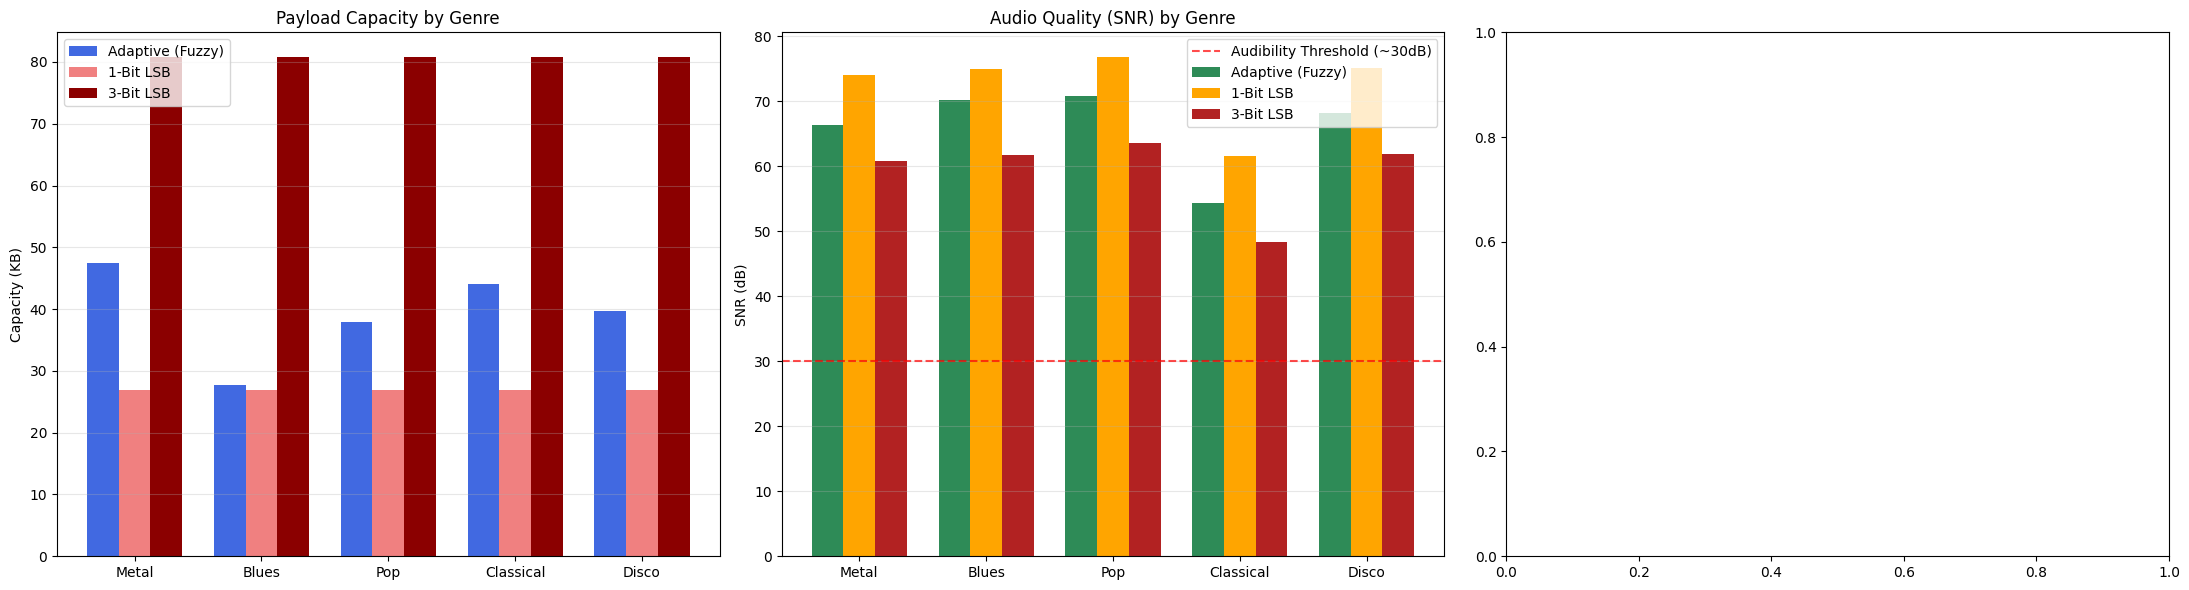

In [14]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

def run_genre_evaluation(base_path, genres_to_test, samples_per_genre=5):
    # Added PESQ arrays to our results dictionary
    results = {
        'Genre': [], 
        'Adapt_Cap': [], 'Adapt_SNR': [], 'Adapt_PESQ': [],
        '1Bit_Cap': [], '1Bit_SNR': [], '1Bit_PESQ': [],
        '3Bit_Cap': [], '3Bit_SNR': [], '3Bit_PESQ': []
    }
    
    env = AudioStegoEnv()
    extractor = FeatureExtractor()
    fuzzy_sys = FuzzyLogicSystem()
    
    # Using our optimized texture-based thresholds
    fuzzy_sys.t_high = 0.40
    fuzzy_sys.t_med = 0.22
    fuzzy_sys.t_low = 0.08
    
    embed_engine = EmbeddingEngine(hop_size=env.hop_size)
    evaluator = Evaluator()
    baselines = BaselineMethods(embed_engine)
    
    for genre in genres_to_test:
        genre_path = os.path.join(base_path, genre, f"{genre}.*.wav")
        files = glob.glob(genre_path)[:samples_per_genre]
        
        if not files:
            print(f"Warning: No files found for {genre} at {genre_path}")
            continue
            
        print(f"Processing [{genre.upper()}]...")
        
        genre_adapt_cap, genre_adapt_snr, genre_adapt_pesq = [], [], []
        genre_1bit_cap, genre_1bit_snr, genre_1bit_pesq = [], [], []
        genre_3bit_cap, genre_3bit_snr, genre_3bit_pesq = [], [], []
        
        for file in files:
            # 1. Load and Extract
            audio_int = env.load_and_preprocess(file)
            audio_float = env.get_audio_float(audio_int)
            features = extractor.extract_features(audio_float)
            
            # 2. Fuzzy Adaptive Run
            scores = fuzzy_sys.compute_scores(features)
            bit_depths = fuzzy_sys.map_to_bits(scores)
            exact_bits = embed_engine.calculate_exact_capacity(bit_depths, len(audio_int))
            payload = embed_engine.generate_random_payload(exact_bits)
            stego_audio = embed_engine.embed(audio_int, bit_depths, payload)
            
            # Notice we capture the 4th output (PESQ) here
            snr, _, _, pesq_val = evaluator.calculate_metrics(audio_int, stego_audio)
            
            genre_adapt_cap.append(exact_bits / (8 * 1024))
            genre_adapt_snr.append(snr)
            genre_adapt_pesq.append(pesq_val)
            
            # 3. 1-Bit Baseline Run
            stego_1bit, bits_1bit = baselines.run_fixed_lsb(audio_int, fixed_depth=1)
            snr_1bit, _, _, pesq_1bit = evaluator.calculate_metrics(audio_int, stego_1bit)
            
            genre_1bit_cap.append(bits_1bit / (8 * 1024))
            genre_1bit_snr.append(snr_1bit)
            genre_1bit_pesq.append(pesq_1bit)
            
            # 4. 3-Bit Baseline Run
            stego_3bit, bits_3bit = baselines.run_fixed_lsb(audio_int, fixed_depth=3)
            snr_3bit, _, _, pesq_3bit = evaluator.calculate_metrics(audio_int, stego_3bit)
            
            genre_3bit_cap.append(bits_3bit / (8 * 1024))
            genre_3bit_snr.append(snr_3bit)
            genre_3bit_pesq.append(pesq_3bit)
            
        # Average the results for the genre
        results['Genre'].append(genre)
        results['Adapt_Cap'].append(np.mean(genre_adapt_cap))
        results['Adapt_SNR'].append(np.mean(genre_adapt_snr))
        results['Adapt_PESQ'].append(np.mean(genre_adapt_pesq))
        
        results['1Bit_Cap'].append(np.mean(genre_1bit_cap))
        results['1Bit_SNR'].append(np.mean(genre_1bit_snr))
        results['1Bit_PESQ'].append(np.mean(genre_1bit_pesq))
        
        results['3Bit_Cap'].append(np.mean(genre_3bit_cap))
        results['3Bit_SNR'].append(np.mean(genre_3bit_snr))
        results['3Bit_PESQ'].append(np.mean(genre_3bit_pesq))
        
    return results

def plot_genre_results(results):
    genres = results['Genre']
    x = np.arange(len(genres))
    width = 0.25 
    
    # Expanded to 3 subplots to accommodate PESQ
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
    
    # --- PLOT 1: Capacity Comparison ---
    ax1.bar(x - width, results['Adapt_Cap'], width, label='Adaptive (Fuzzy)', color='royalblue')
    ax1.bar(x, results['1Bit_Cap'], width, label='1-Bit LSB', color='lightcoral')
    ax1.bar(x + width, results['3Bit_Cap'], width, label='3-Bit LSB', color='darkred')
    
    ax1.set_ylabel('Capacity (KB)')
    ax1.set_title('Payload Capacity by Genre')
    ax1.set_xticks(x)
    ax1.set_xticklabels([g.capitalize() for g in genres])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # --- PLOT 2: SNR Comparison ---
    ax2.bar(x - width, results['Adapt_SNR'], width, label='Adaptive (Fuzzy)', color='seagreen')
    ax2.bar(x, results['1Bit_SNR'], width, label='1-Bit LSB', color='orange')
    ax2.bar(x + width, results['3Bit_SNR'], width, label='3-Bit LSB', color='firebrick')
    
    ax2.set_ylabel('SNR (dB)')
    ax2.set_title('Audio Quality (SNR) by Genre')
    ax2.set_xticks(x)
    ax2.set_xticklabels([g.capitalize() for g in genres])
    ax2.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Audibility Threshold (~30dB)')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # # --- PLOT 3: PESQ Comparison (NEW) ---
    # ax3.bar(x - width, results['Adapt_PESQ'], width, label='Adaptive (Fuzzy)', color='mediumpurple')
    # ax3.bar(x, results['1Bit_PESQ'], width, label='1-Bit LSB', color='plum')
    # ax3.bar(x + width, results['3Bit_PESQ'], width, label='3-Bit LSB', color='indigo')
    
    # ax3.set_ylabel('PESQ Score (MOS)')
    # ax3.set_title('Perceived Distortion (PESQ) by Genre')
    # ax3.set_xticks(x)
    # ax3.set_xticklabels([g.capitalize() for g in genres])
    # # Add a line showing the "Excellent" threshold for human hearing
    # ax3.axhline(y=4.0, color='g', linestyle='--', alpha=0.7, label='Excellent Quality Threshold')
    # ax3.legend()
    # ax3.grid(axis='y', alpha=0.3)
    # # Lock the Y-axis limit to the standard PESQ scale
    # ax3.set_ylim([1.0, 4.6]) 
    
    plt.tight_layout()
    plt.show()

# Set up your dataset path here
gtzan_base_path = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original"
genres_to_test = ['metal', 'blues', 'pop', 'classical', 'disco']

# Run the evaluation and plot!
print("Starting Full Evaluation Pipeline with Perceptual Metrics...")
final_results = run_genre_evaluation(gtzan_base_path, genres_to_test)
plot_genre_results(final_results)

In [15]:
# --- EQUAL PAYLOAD COMPARISON (ISO-CAPACITY) ---

print("--- EQUAL PAYLOAD COMPARISON ---")

# 1. Calculate the maximum theoretical capacities for this specific track
scores = fuzzy_sys.compute_scores(features)
adapt_depths = fuzzy_sys.map_to_bits(scores)
max_adapt_bits = embed_engine.calculate_exact_capacity(adapt_depths, len(audio_int))

num_frames = int(np.ceil(len(audio_int) / embed_engine.hop_size))
depths_1bit = np.full(num_frames, 1, dtype=np.uint8)
max_1bit_bits = embed_engine.calculate_exact_capacity(depths_1bit, len(audio_int))

# 2. Find the Minimum Common Payload (so no method overflows)
# We usually take 90% of the minimum just to be safe and ensure everyone finishes
target_payload_bits = int(min(max_adapt_bits, max_1bit_bits) * 0.90)
target_kb = target_payload_bits / (8 * 1024)

print(f"Target Fixed Payload: {target_kb:.2f} KB")
print("-" * 32)

# Generate ONE shared secret message for all three methods
shared_payload = embed_engine.generate_random_payload(target_payload_bits)

# --- 1. ADAPTIVE EVALUATION ---
stego_adapt = embed_engine.embed(audio_int, adapt_depths, shared_payload)
snr_a, _, psnr_a, pesq_a = evaluator.calculate_metrics(audio_int, stego_adapt)
print(f"[Adaptive Fuzzy]   SNR: {snr_a:.2f} dB | PESQ: {pesq_a:.2f} MOS")

# --- 2. 1-BIT EVALUATION ---
stego_1bit = embed_engine.embed(audio_int, depths_1bit, shared_payload)
snr_1, _, psnr_1, pesq_1 = evaluator.calculate_metrics(audio_int, stego_1bit)
print(f"[Standard 1-Bit]   SNR: {snr_1:.2f} dB | PESQ: {pesq_1:.2f} MOS")

# --- 3. 3-BIT EVALUATION ---
depths_3bit = np.full(num_frames, 3, dtype=np.uint8)
stego_3bit = embed_engine.embed(audio_int, depths_3bit, shared_payload)
snr_3, _, psnr_3, pesq_3 = evaluator.calculate_metrics(audio_int, stego_3bit)
print(f"[Fixed 3-Bit]      SNR: {snr_3:.2f} dB | PESQ: {pesq_3:.2f} MOS")

--- EQUAL PAYLOAD COMPARISON ---
Target Fixed Payload: 24.22 KB
--------------------------------
[Adaptive Fuzzy]   SNR: 47.60 dB | PESQ: 4.32 MOS
[Standard 1-Bit]   SNR: 54.67 dB | PESQ: 4.59 MOS
[Fixed 3-Bit]      SNR: 45.67 dB | PESQ: 3.89 MOS


Starting Rate-Distortion Evaluation...
Generating Rate-Distortion Curve for [METAL]...
Generating Rate-Distortion Curve for [BLUES]...
Generating Rate-Distortion Curve for [POP]...
Generating Rate-Distortion Curve for [CLASSICAL]...


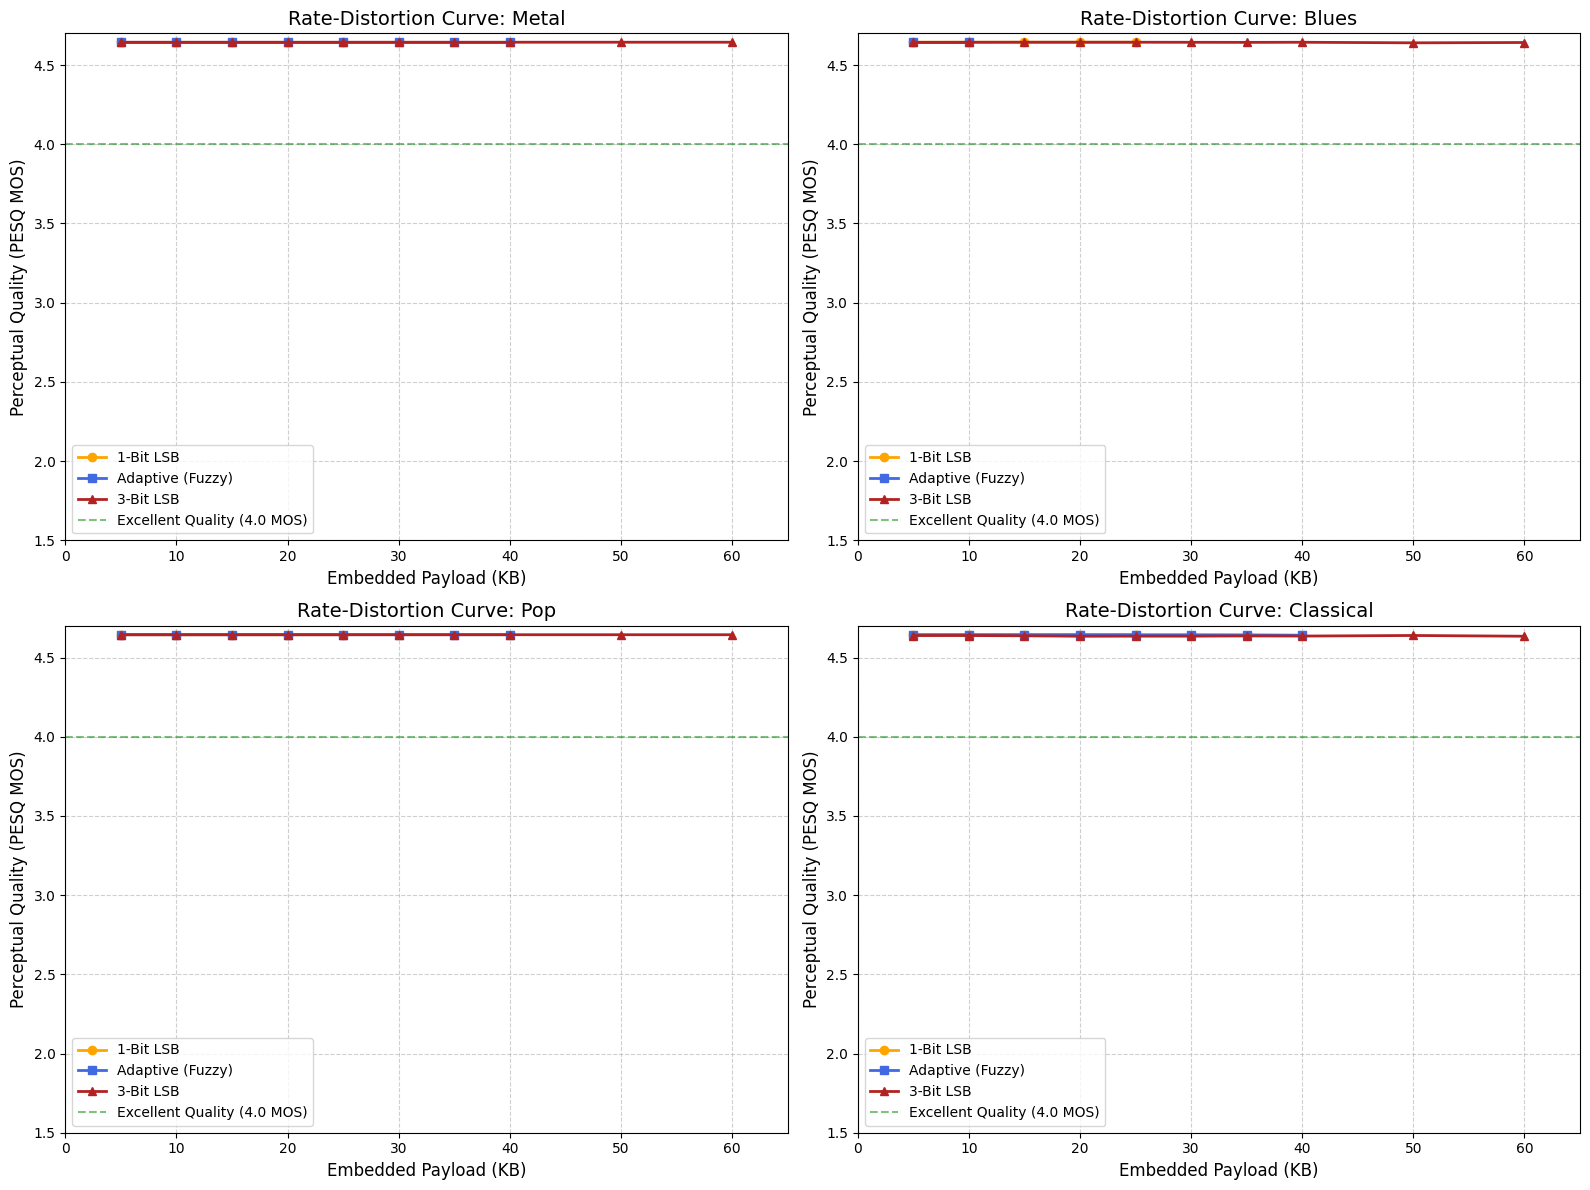

In [16]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

def run_degradation_curves(base_path, genres_to_test):
    # Payload checkpoints to test (in KB)
    checkpoints_kb = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
    
    env = AudioStegoEnv()
    extractor = FeatureExtractor()
    fuzzy_sys = FuzzyLogicSystem()
    fuzzy_sys.t_high = 0.40
    fuzzy_sys.t_med = 0.22
    fuzzy_sys.t_low = 0.08
    
    embed_engine = EmbeddingEngine(hop_size=env.hop_size)
    evaluator = Evaluator()
    
    # Dictionary to store the curve data for each genre
    genre_curves = {}

    for genre in genres_to_test:
        genre_path = os.path.join(base_path, genre, f"{genre}.*.wav")
        # We will test 1 representative file per genre to generate clean curves
        # You can increase this to average multiple files, but 1 is great for a clear graph
        file = glob.glob(genre_path)[0] 
        
        print(f"Generating Rate-Distortion Curve for [{genre.upper()}]...")
        
        # 1. Load Audio and Features
        audio_int = env.load_and_preprocess(file)
        audio_float = env.get_audio_float(audio_int)
        features = extractor.extract_features(audio_float)
        
        # 2. Calculate Maximum Capacities
        scores = fuzzy_sys.compute_scores(features)
        adapt_depths = fuzzy_sys.map_to_bits(scores)
        max_adapt_bits = embed_engine.calculate_exact_capacity(adapt_depths, len(audio_int))
        
        num_frames = int(np.ceil(len(audio_int) / embed_engine.hop_size))
        depths_1bit = np.full(num_frames, 1, dtype=np.uint8)
        max_1bit_bits = embed_engine.calculate_exact_capacity(depths_1bit, len(audio_int))
        
        depths_3bit = np.full(num_frames, 3, dtype=np.uint8)
        max_3bit_bits = embed_engine.calculate_exact_capacity(depths_3bit, len(audio_int))
        
        # Initialize arrays for this genre's lines
        pesq_adapt, pesq_1bit, pesq_3bit = [], [], []
        
        # 3. Step through the Checkpoints
        for target_kb in checkpoints_kb:
            target_bits = int(target_kb * 8 * 1024)
            payload = embed_engine.generate_random_payload(target_bits)
            
            # --- Evaluate 1-Bit ---
            if target_bits <= max_1bit_bits:
                stego_1 = embed_engine.embed(audio_int, depths_1bit, payload)
                _, _, _, p_1 = evaluator.calculate_metrics(audio_int, stego_1)
                pesq_1bit.append(p_1)
            else:
                pesq_1bit.append(np.nan) # Line stops here
                
            # --- Evaluate 3-Bit ---
            if target_bits <= max_3bit_bits:
                stego_3 = embed_engine.embed(audio_int, depths_3bit, payload)
                _, _, _, p_3 = evaluator.calculate_metrics(audio_int, stego_3)
                pesq_3bit.append(p_3)
            else:
                pesq_3bit.append(np.nan)
                
            # --- Evaluate Adaptive ---
            if target_bits <= max_adapt_bits:
                stego_a = embed_engine.embed(audio_int, adapt_depths, payload)
                _, _, _, p_a = evaluator.calculate_metrics(audio_int, stego_a)
                pesq_adapt.append(p_a)
            else:
                pesq_adapt.append(np.nan)
                
        # Store for plotting
        genre_curves[genre] = {
            '1Bit': pesq_1bit,
            '3Bit': pesq_3bit,
            'Adapt': pesq_adapt
        }
        
    return checkpoints_kb, genre_curves

def plot_degradation_curves(checkpoints_kb, genre_curves):
    genres = list(genre_curves.keys())
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, genre in enumerate(genres):
        ax = axes[idx]
        data = genre_curves[genre]
        
        # Plot the lines (Matplotlib automatically ignores np.nan, breaking the line perfectly)
        ax.plot(checkpoints_kb, data['1Bit'], marker='o', linewidth=2, color='orange', label='1-Bit LSB')
        ax.plot(checkpoints_kb, data['Adapt'], marker='s', linewidth=2, color='royalblue', label='Adaptive (Fuzzy)')
        ax.plot(checkpoints_kb, data['3Bit'], marker='^', linewidth=2, color='firebrick', label='3-Bit LSB')
        
        ax.axhline(y=4.0, color='g', linestyle='--', alpha=0.5, label='Excellent Quality (4.0 MOS)')
        
        ax.set_title(f'Rate-Distortion Curve: {genre.capitalize()}', fontsize=14)
        ax.set_xlabel('Embedded Payload (KB)', fontsize=12)
        ax.set_ylabel('Perceptual Quality (PESQ MOS)', fontsize=12)
        ax.set_ylim([1.5, 4.7]) # Lock Y-axis to standard PESQ scale
        ax.set_xlim([0, 65])
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='lower left')
        
    plt.tight_layout()
    plt.show()

# Set up your dataset path here
gtzan_base_path = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original"
genres_to_test = ['metal', 'blues', 'pop', 'classical']

# Run the evaluation and plot!
print("Starting Rate-Distortion Evaluation...")
checkpoints, curves = run_degradation_curves(gtzan_base_path, genres_to_test)
plot_degradation_curves(checkpoints, curves)

Starting PSNR Rate-Distortion Evaluation...
Generating PSNR Rate-Distortion Curve for [METAL]...
Generating PSNR Rate-Distortion Curve for [BLUES]...
Generating PSNR Rate-Distortion Curve for [POP]...
Generating PSNR Rate-Distortion Curve for [CLASSICAL]...


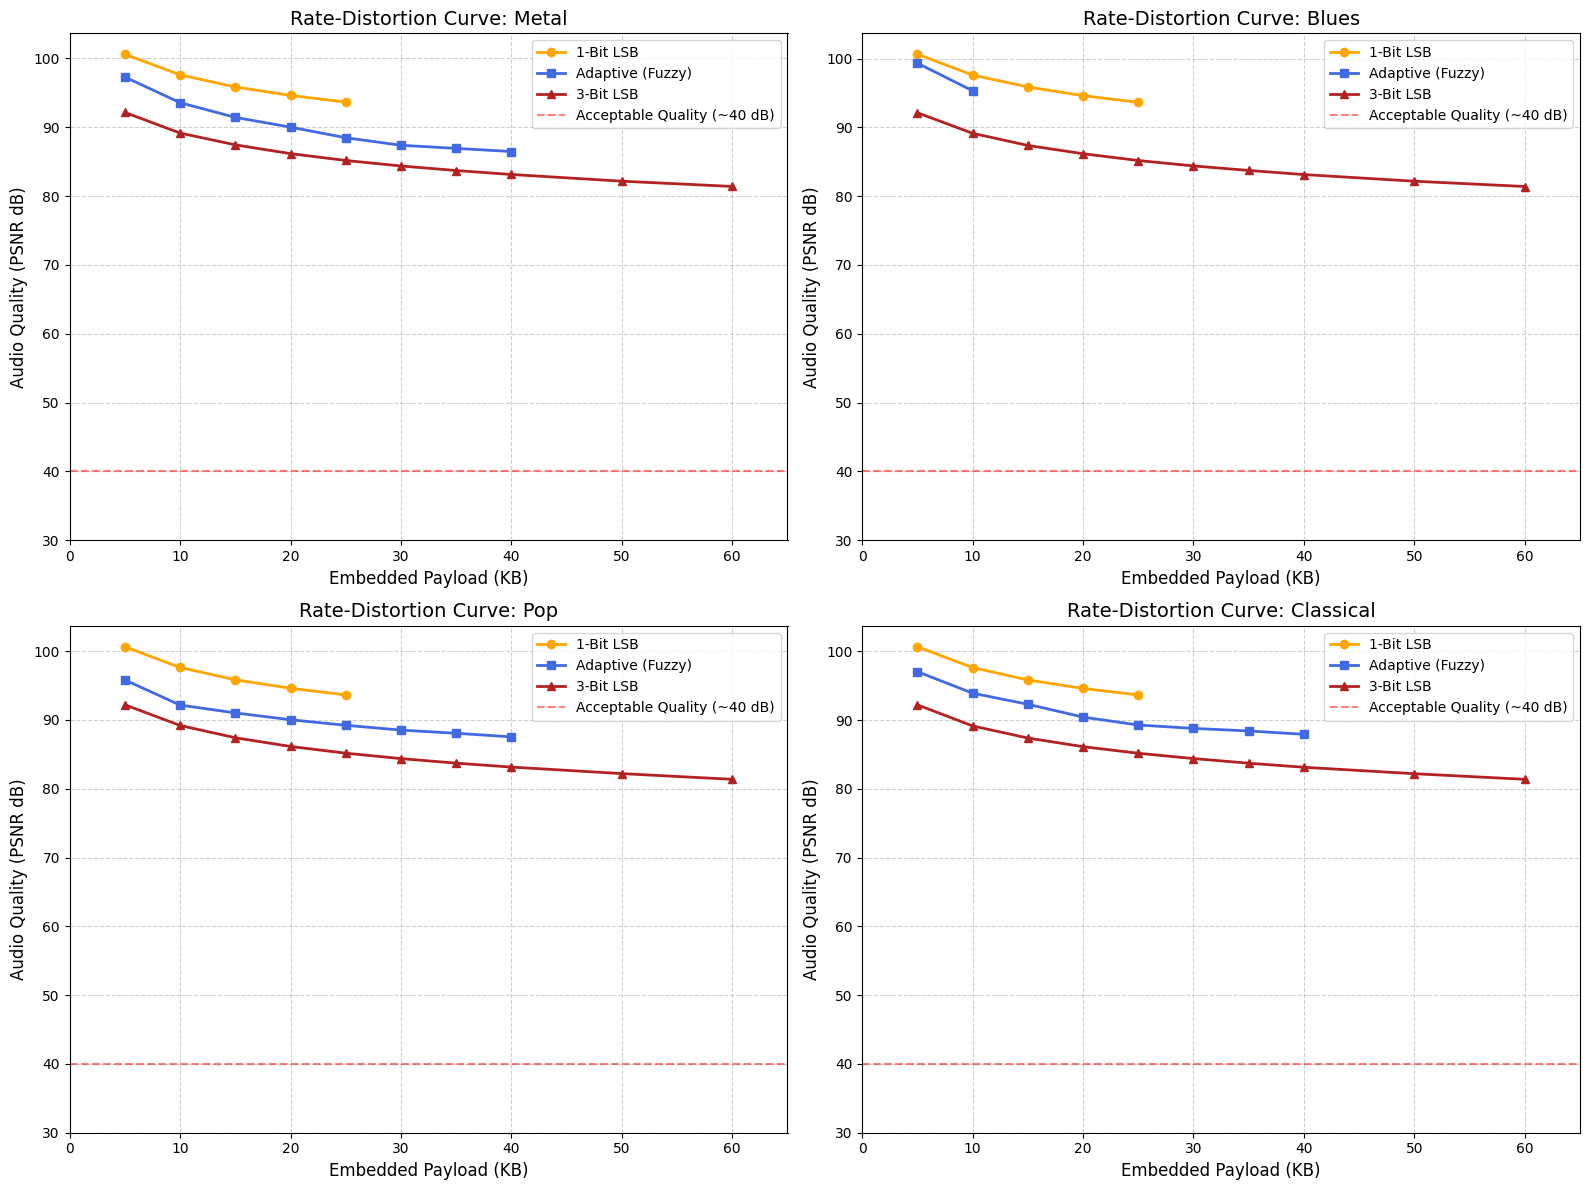

In [17]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

def run_psnr_degradation_curves(base_path, genres_to_test):
    # Payload checkpoints to test (in KB)
    checkpoints_kb = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
    
    env = AudioStegoEnv()
    extractor = FeatureExtractor()
    fuzzy_sys = FuzzyLogicSystem()
    fuzzy_sys.t_high = 0.40
    fuzzy_sys.t_med = 0.22
    fuzzy_sys.t_low = 0.08
    
    embed_engine = EmbeddingEngine(hop_size=env.hop_size)
    evaluator = Evaluator()
    
    # Dictionary to store the curve data for each genre
    genre_curves = {}

    for genre in genres_to_test:
        genre_path = os.path.join(base_path, genre, f"{genre}.*.wav")
        file = glob.glob(genre_path)[0] 
        
        print(f"Generating PSNR Rate-Distortion Curve for [{genre.upper()}]...")
        
        # 1. Load Audio and Features
        audio_int = env.load_and_preprocess(file)
        audio_float = env.get_audio_float(audio_int)
        features = extractor.extract_features(audio_float)
        
        # 2. Calculate Maximum Capacities
        scores = fuzzy_sys.compute_scores(features)
        adapt_depths = fuzzy_sys.map_to_bits(scores)
        max_adapt_bits = embed_engine.calculate_exact_capacity(adapt_depths, len(audio_int))
        
        num_frames = int(np.ceil(len(audio_int) / embed_engine.hop_size))
        depths_1bit = np.full(num_frames, 1, dtype=np.uint8)
        max_1bit_bits = embed_engine.calculate_exact_capacity(depths_1bit, len(audio_int))
        
        depths_3bit = np.full(num_frames, 3, dtype=np.uint8)
        max_3bit_bits = embed_engine.calculate_exact_capacity(depths_3bit, len(audio_int))
        
        # Initialize arrays for this genre's lines (Now tracking PSNR)
        psnr_adapt, psnr_1bit, psnr_3bit = [], [], []
        
        # 3. Step through the Checkpoints
        for target_kb in checkpoints_kb:
            target_bits = int(target_kb * 8 * 1024)
            payload = embed_engine.generate_random_payload(target_bits)
            
            # --- Evaluate 1-Bit ---
            if target_bits <= max_1bit_bits:
                stego_1 = embed_engine.embed(audio_int, depths_1bit, payload)
                # Notice we capture the 3rd output (PSNR) now
                _, _, p_1, _ = evaluator.calculate_metrics(audio_int, stego_1)
                psnr_1bit.append(p_1)
            else:
                psnr_1bit.append(np.nan) # Line stops here
                
            # --- Evaluate 3-Bit ---
            if target_bits <= max_3bit_bits:
                stego_3 = embed_engine.embed(audio_int, depths_3bit, payload)
                _, _, p_3, _ = evaluator.calculate_metrics(audio_int, stego_3)
                psnr_3bit.append(p_3)
            else:
                psnr_3bit.append(np.nan)
                
            # --- Evaluate Adaptive ---
            if target_bits <= max_adapt_bits:
                stego_a = embed_engine.embed(audio_int, adapt_depths, payload)
                _, _, p_a, _ = evaluator.calculate_metrics(audio_int, stego_a)
                psnr_adapt.append(p_a)
            else:
                psnr_adapt.append(np.nan)
                
        # Store for plotting
        genre_curves[genre] = {
            '1Bit': psnr_1bit,
            '3Bit': psnr_3bit,
            'Adapt': psnr_adapt
        }
        
    return checkpoints_kb, genre_curves

def plot_psnr_degradation_curves(checkpoints_kb, genre_curves):
    genres = list(genre_curves.keys())
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, genre in enumerate(genres):
        ax = axes[idx]
        data = genre_curves[genre]
        
        ax.plot(checkpoints_kb, data['1Bit'], marker='o', linewidth=2, color='orange', label='1-Bit LSB')
        ax.plot(checkpoints_kb, data['Adapt'], marker='s', linewidth=2, color='royalblue', label='Adaptive (Fuzzy)')
        ax.plot(checkpoints_kb, data['3Bit'], marker='^', linewidth=2, color='firebrick', label='3-Bit LSB')
        
        # Switched the threshold line to 40 dB (Acceptable Audio Steganography threshold)
        ax.axhline(y=40.0, color='r', linestyle='--', alpha=0.5, label='Acceptable Quality (~40 dB)')
        
        ax.set_title(f'Rate-Distortion Curve: {genre.capitalize()}', fontsize=14)
        ax.set_xlabel('Embedded Payload (KB)', fontsize=12)
        ax.set_ylabel('Audio Quality (PSNR dB)', fontsize=12)
        ax.set_xlim([0, 65])
        
        # PSNR generally ranges from ~40 to ~100 in these tests. 
        # We let Matplotlib auto-scale the top, but lock the bottom at 30 so the 3-bit drop is visible.
        ax.set_ylim(bottom=30) 
        
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='upper right')
        
    plt.tight_layout()
    plt.show()

# Set up your dataset path here
gtzan_base_path = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original"
genres_to_test = ['metal', 'blues', 'pop', 'classical']

# Run the evaluation and plot!
print("Starting PSNR Rate-Distortion Evaluation...")
checkpoints, curves = run_psnr_degradation_curves(gtzan_base_path, genres_to_test)
plot_psnr_degradation_curves(checkpoints, curves)